In [146]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
from matplotlib import rc
import matplotlib.gridspec as gridspec
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
import glob
import os
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle, Patch
import matplotlib.lines as mlines
from matplotlib.collections import LineCollection
from matplotlib.container import ErrorbarContainer
import matplotlib.ticker as ticker

In [147]:
# ----------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------
n_best=2440
rsl=xr.open_dataset("../../FesmData/GAPSLIP_Gowan2023_GrIS/output/rsl_dataset_reduced.nc")
yelmo=xr.open_dataset("../output/ensemble_rsl.nc")
present = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")

best = yelmo.sel(sim=n_best)

In [148]:

reg_list=[]

for reg in rsl.region:
    sim = rsl.sel(region = reg)
    x, y = sim.xc.values, sim.yc.values
    subreg=rg.sel(xc=x, yc=y, method="nearest").mask.values
    reg_list.append(subreg.item())

rsl.coords['basin_reg'] = ('region', np.array(reg_list))

In [156]:
rsl

<xarray.Dataset> Size: 190kB
Dimensions:      (region: 47, obs: 97)
Coordinates:
  * region       (region) <U25 5kB 'Akulliit' 'Alluttoq_Island' ... 'Young_Sund'
    xc           (region) float64 376B ...
    yc           (region) float64 376B ...
    xc_min       (region) float64 376B ...
    xc_max       (region) float64 376B ...
    yc_min       (region) float64 376B ...
    yc_max       (region) float64 376B ...
    n_sites      (region) int64 376B ...
    basin_reg    (region) float64 376B 3.0 3.0 5.0 8.0 7.0 ... 2.0 8.0 8.0 7.0
Dimensions without coordinates: obs
Data variables:
    time         (region, obs) float64 36kB ...
    time_err     (region, obs) float64 36kB ...
    RSL          (region, obs) float64 36kB ...
    RSL_err_min  (region, obs) float64 36kB ...
    RSL_err_max  (region, obs) float64 36kB ...

In [160]:
def add_panel_rsl_ensemble(ax, yelmo, rsl,best):
    # yelmo: ensemble
    # rsl: GAPSLIP data
    ax.errorbar(-rsl.time*1e-3, rsl.RSL, 
                xerr=rsl.time_err*1e-3,
                yerr=[rsl.RSL_err_min, rsl.RSL_err_max],
                fmt='^', color='black', ecolor='black', markersize=6,
                markerfacecolor='pink',      # relleno rojo
                markeredgecolor='black',    # borde negro
                markeredgewidth=0.8, capsize=2,zorder=5)

    for sim_idx in yelmo.sim:
        ax.plot(yelmo.time*1e-3, 
        yelmo.rsl.sel(sim=sim_idx), 
        "-", color="#b6b6b6", alpha=0.3,zorder=0)
    
    ax.plot(best.time*1e-3, best.rsl,"-", color="black", zorder=2)
    
    ax.text(0.05, 0.1, rsl.region.values,
    transform=ax.transAxes,ha='left',va='top')
    return

plt.rcParams.update({'font.size': 12})

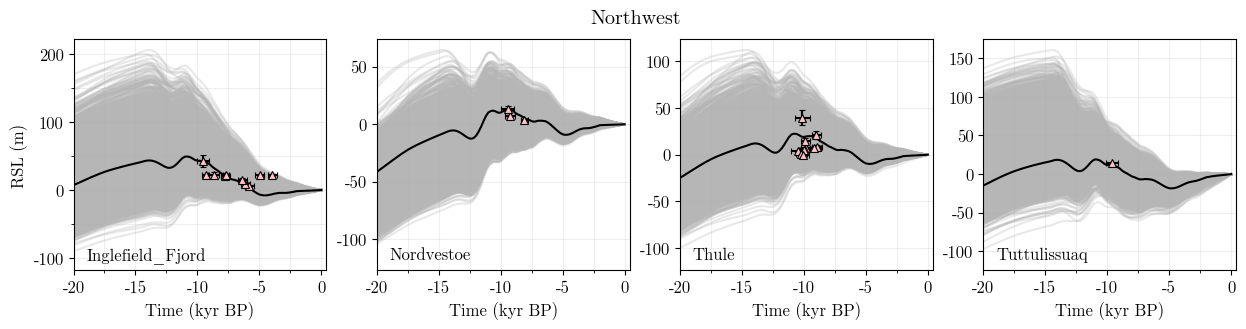

In [161]:
# NW 
ds_regions = rsl.region.where(rsl.basin_reg==2)
index = np.where(pd.notnull(ds_regions))

fig, axs = plt.subplots(1, 4, figsize=(15, 3))
j=0
for i in index[0]:
    ax = axs[j]
    data=rsl.sel(region=rsl.region[i])
    yl=yelmo.sel(region=rsl.region[i])
    bt=best.sel(region=rsl.region[i])
    add_panel_rsl_ensemble(ax, yl, data,bt)
    j+=1


axs[0].set_ylabel("RSL (m)")
for ax in axs:
    ax.set_xlim(-20, 0.4)
    ax.set_xlabel("Time (kyr BP)")
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(2.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.grid(which="both",alpha=0.2)

fig.suptitle("Northwest")
fig.savefig(f"../figs/ensemble_rsl_nw_{n_best}.png", dpi=300, bbox_inches='tight')

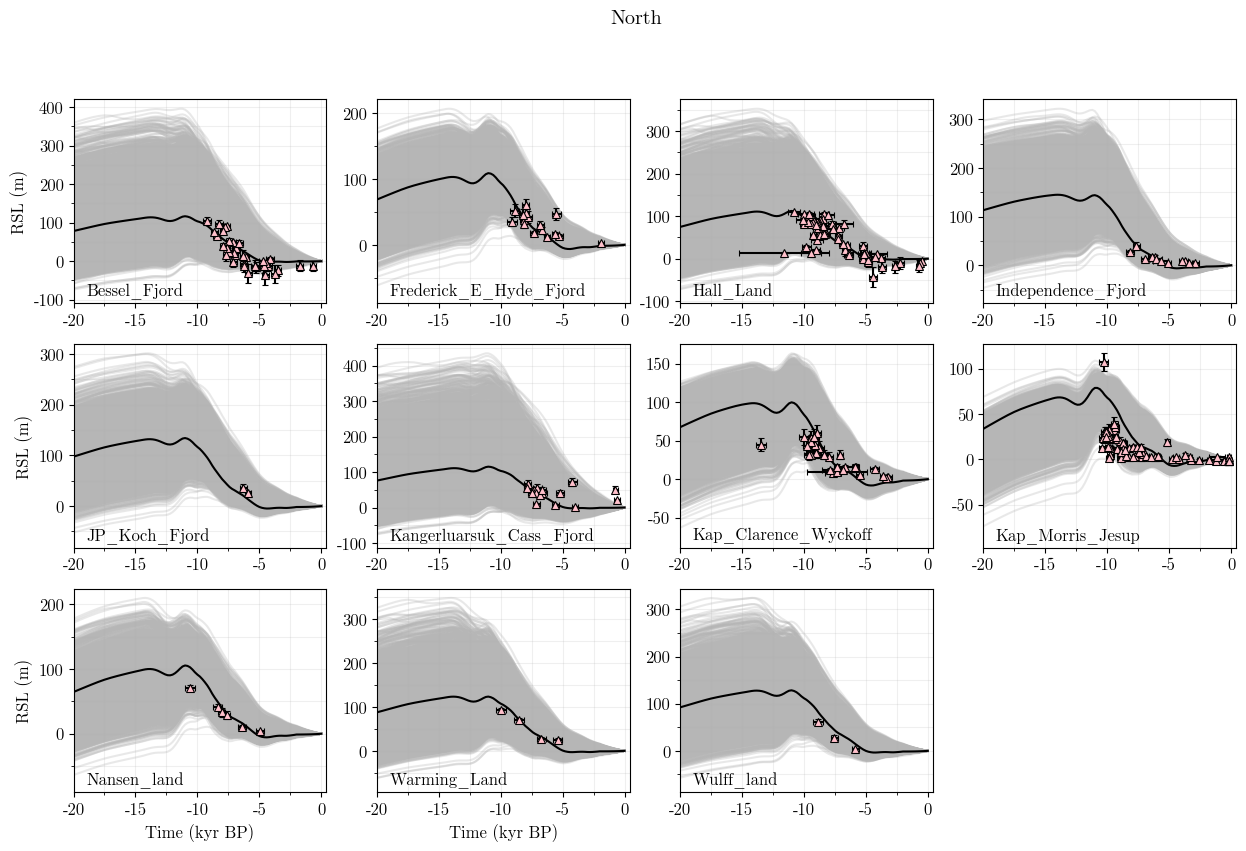

In [162]:
# North
ds_regions = rsl.region.where(rsl.basin_reg==8)
index = np.where(pd.notnull(ds_regions))

fig, axs = plt.subplots(3, 4, figsize=(15, 9))
axs = axs.flatten()

j=0
for i in index[0]:
    ax = axs[j]
    data=rsl.sel(region=rsl.region[i])
    yl=yelmo.sel(region=rsl.region[i])
    bt=best.sel(region=rsl.region[i])
    add_panel_rsl_ensemble(ax, yl, data,bt)
    j+=1

axs[0].set_ylabel("RSL (m)")
axs[4].set_ylabel("RSL (m)")
axs[8].set_ylabel("RSL (m)")
for ax in axs[8:10]: 
    ax.set_xlabel("Time (kyr BP)")
axs[11].axis('off')
for ax in axs:
    ax.set_xlim(-20, 0.4)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(2.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.grid(which="both",alpha=0.2)
    
fig.suptitle("North")
fig.savefig(f"../figs/ensemble_rsl_n_{n_best}.png", dpi=300, bbox_inches='tight')

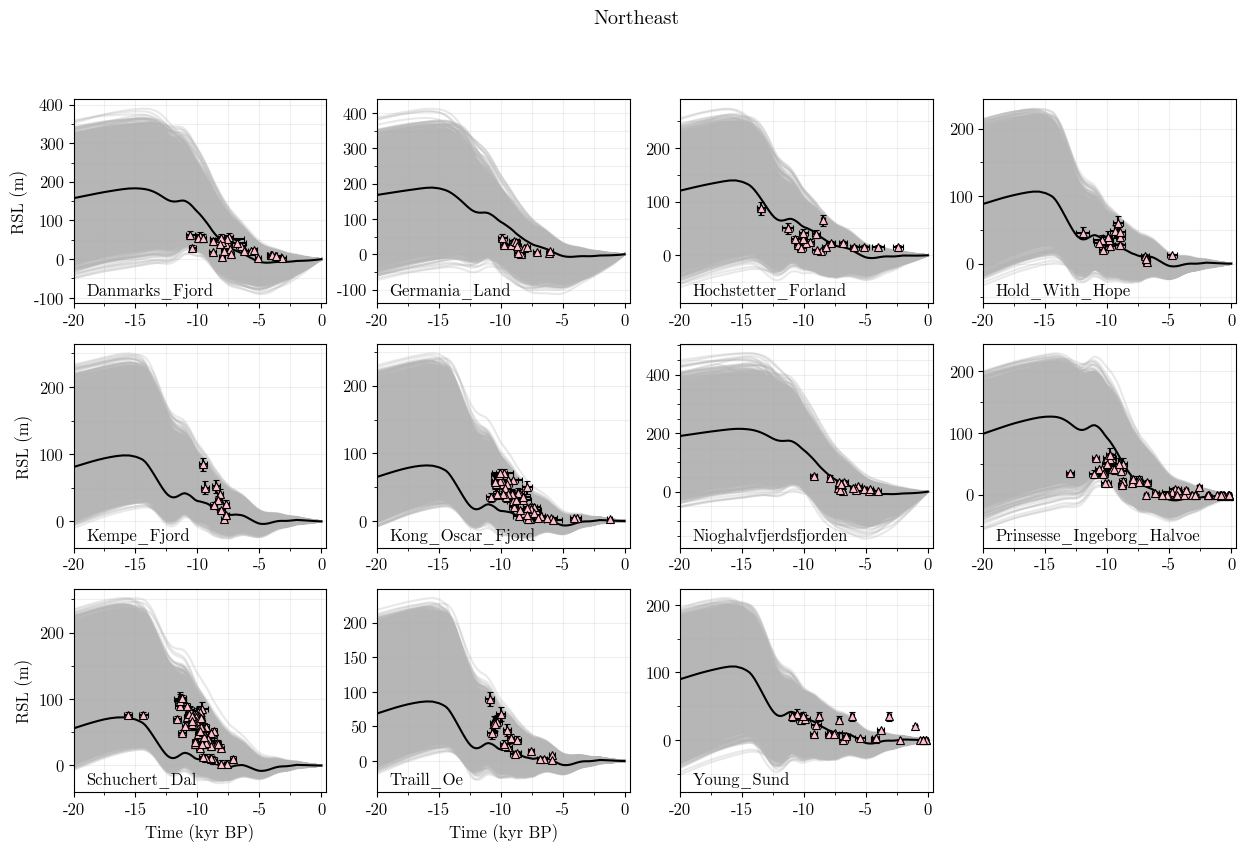

In [163]:
# Northeast
ds_regions = rsl.region.where(rsl.basin_reg==7)
index = np.where(pd.notnull(ds_regions))

fig, axs = plt.subplots(3, 4, figsize=(15, 9))
axs = axs.flatten()

j=0
for i in index[0]:
    ax = axs[j]
    data=rsl.sel(region=rsl.region[i])
    yl=yelmo.sel(region=rsl.region[i])
    bt=best.sel(region=rsl.region[i])
    add_panel_rsl_ensemble(ax, yl, data,bt)
    j+=1

axs[0].set_ylabel("RSL (m)")
axs[4].set_ylabel("RSL (m)")
axs[8].set_ylabel("RSL (m)")
for ax in axs[8:10]: 
    ax.set_xlabel("Time (kyr BP)")
axs[11].axis('off')
for ax in axs:
    ax.set_xlim(-20, 0.4)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(2.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.grid(which="both",alpha=0.2)
    
fig.suptitle("Northeast")
fig.savefig(f"../figs/ensemble_rsl_ne_{n_best}.png", dpi=300, bbox_inches='tight')

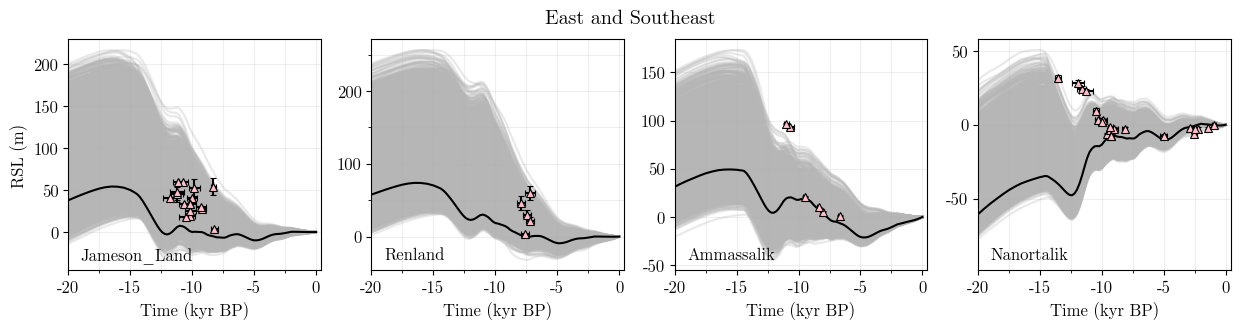

In [164]:
# East and Southeast
ds_regions = rsl.region.where(rsl.basin_reg==6)
index1 = np.where(pd.notnull(ds_regions))

ds_regions = rsl.region.where(rsl.basin_reg==5)
index2 = np.where(pd.notnull(ds_regions))

index= (np.concatenate((index1[0], index2[0])))

fig, axs = plt.subplots(1, 4, figsize=(15, 3))
j=0
for i in index:
    ax = axs[j]
    data=rsl.sel(region=rsl.region[i])
    yl=yelmo.sel(region=rsl.region[i])
    bt=best.sel(region=rsl.region[i])
    add_panel_rsl_ensemble(ax, yl, data,bt)
    j+=1


axs[0].set_ylabel("RSL (m)")
for ax in axs:
    ax.set_xlim(-20, 0.4)
    ax.set_xlabel("Time (kyr BP)")
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(2.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.grid(which="both",alpha=0.2)
    
fig.suptitle("East and Southeast")
fig.savefig(f"../figs/ensemble_rsl_ese_{n_best}.png", dpi=300, bbox_inches='tight')

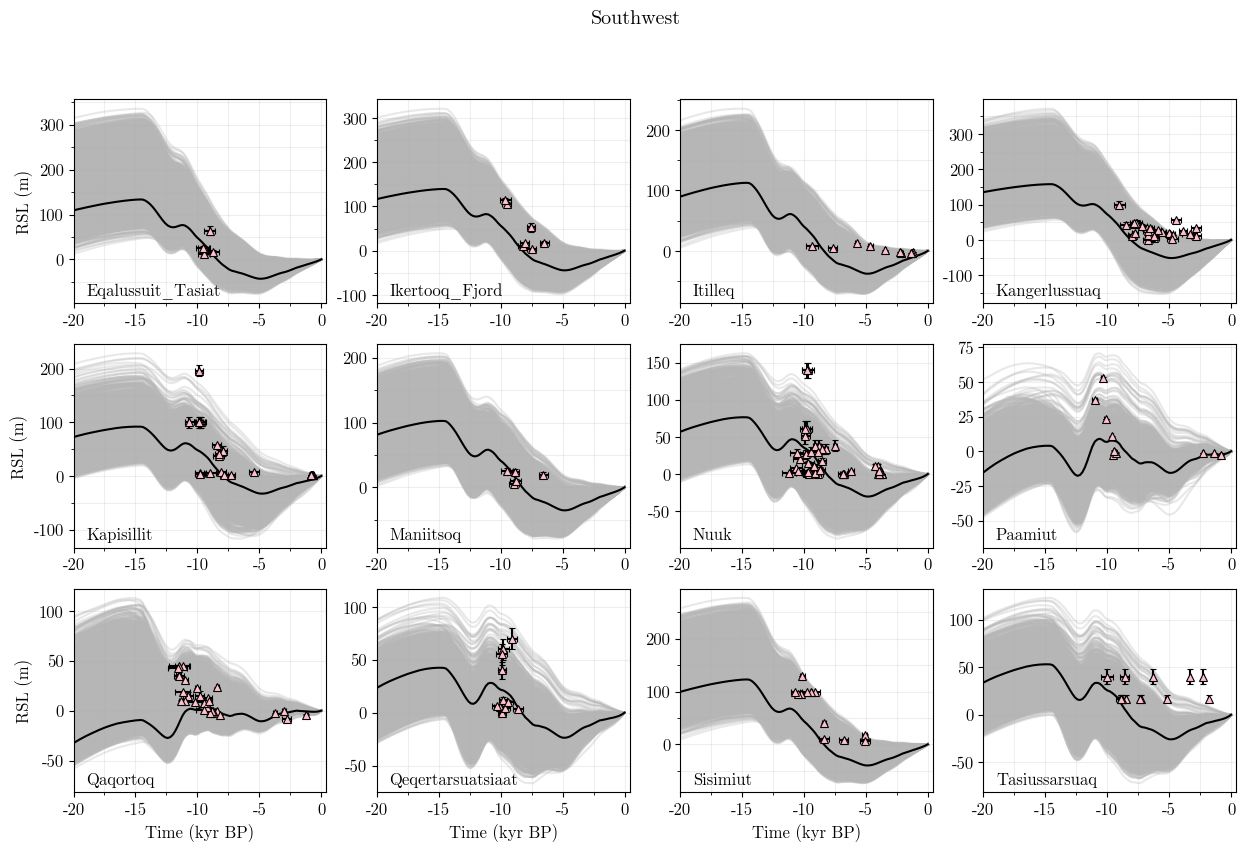

In [165]:
# Southwest
ds_regions = rsl.region.where(rsl.basin_reg==4)
index = np.where(pd.notnull(ds_regions))

fig, axs = plt.subplots(3, 4, figsize=(15, 9))
axs = axs.flatten()

j=0
for i in index[0]:
    ax = axs[j]
    data=rsl.sel(region=rsl.region[i])
    yl=yelmo.sel(region=rsl.region[i])
    bt=best.sel(region=rsl.region[i])
    add_panel_rsl_ensemble(ax, yl, data,bt)
    j+=1

axs[0].set_ylabel("RSL (m)")
axs[4].set_ylabel("RSL (m)")
axs[8].set_ylabel("RSL (m)")
for ax in axs[8:11]: 
    ax.set_xlabel("Time (kyr BP)")
for ax in axs:
    ax.set_xlim(-20, 0.4)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(2.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.grid(which="both",alpha=0.2)
    
fig.suptitle("Southwest")
fig.savefig(f"../figs/ensemble_rsl_sw_{n_best}.png", dpi=300, bbox_inches='tight')

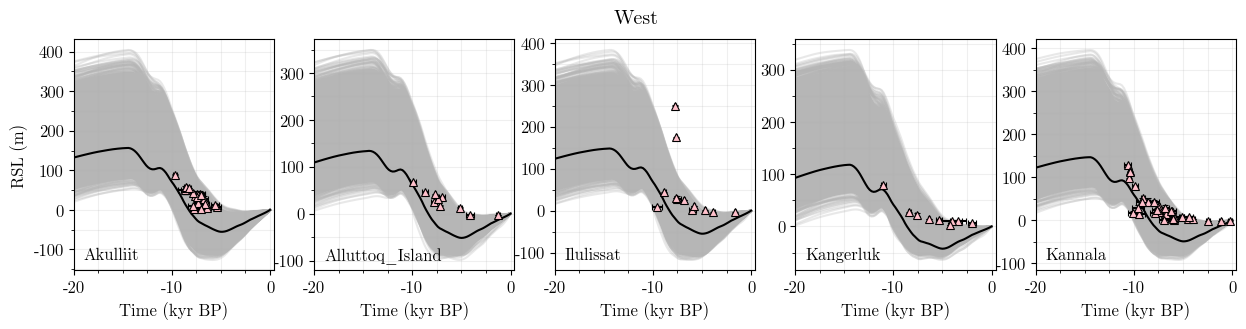

In [166]:
# West
ds_regions = rsl.region.where(rsl.basin_reg==3)
index = np.where(pd.notnull(ds_regions))

fig, axs = plt.subplots(1, 5, figsize=(15, 3))
j=0
for i in index[0]:
    ax = axs[j]
    data=rsl.sel(region=rsl.region[i])
    yl=yelmo.sel(region=rsl.region[i])
    bt=best.sel(region=rsl.region[i])
    add_panel_rsl_ensemble(ax, yl, data,bt)
    j+=1


axs[0].set_ylabel("RSL (m)")
for ax in axs:
    ax.set_xlim(-20, 0.4)
    ax.set_xlabel("Time (kyr BP)")
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(2.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax.grid(which="both",alpha=0.2)

fig.suptitle("West")
fig.savefig(f"../figs/ensemble_rsl_w_{n_best}.png", dpi=300, bbox_inches='tight')